<a href="https://colab.research.google.com/github/jpnoug/spectropy/blob/main/nova_2026rdg_Halpha.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Nova AT 2026rdg (Nova Aql 2026) — évolution de Hα en émission

Comparaison de deux spectres Alpy 600 (Newton 200) des **6** et **9 juillet 2026**.

Les deux spectres sont recalés sur un continuum commun (médiane dans une fenêtre voisine de Hα, hors raies) afin de comparer directement l'intensité relative de la raie.

In [1]:
# --- Sur Colab : décommenter pour charger les fichiers ---
from google.colab import files
uploaded = files.upload()   # sélectionner les deux .fit

import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

FILES = {
    '2026-07-06': '_2026rdg_20260706_899_t6A.fit',
    '2026-07-09': '_2026rdg_20260709_877_t6A.fit',
}

Saving _2026rdg_20260709_877.fits to _2026rdg_20260709_877.fits


In [2]:
def load_spectrum(path):
    """Retourne (wavelength [Angstrom], flux) depuis un FITS 1D linéaire."""
    with fits.open(path) as hdul:
        h = hdul[0].header
        flux = hdul[0].data.astype(float)
        n = h['NAXIS1']
        crpix = h.get('CRPIX1', 1)
        wl = h['CRVAL1'] + (np.arange(n) + 1 - crpix) * h['CDELT1']
        meta = {
            'date': h.get('DATE-OBS', '?'),
            'exptime': h.get('EXPTIME', np.nan),
        }
    return wl, flux, meta

spectra = {label: load_spectrum(f) for label, f in FILES.items()}
for label, (wl, flux, meta) in spectra.items():
    print(f"{label}: {wl[0]:.1f}–{wl[-1]:.1f} Å, {len(wl)} pts, "
          f"exp={meta['exptime']}s, DATE-OBS={meta['date']}")

2026-07-06: 3506.5–7605.5 Å, 8200 pts, exp=3614s, DATE-OBS=2026-07-06T21:34:45
2026-07-09: 3506.5–7604.5 Å, 8198 pts, exp=5197s, DATE-OBS=2026-07-09T21:02:25


In [3]:
# --- Recalage du continuum ---
# Fenêtre proche de Hα mais hors raies (évite Hα 6562.8 et [N II] 6548/6583).
CONT_WIN = (6600.0, 6660.0)

def continuum_level(wl, flux, win=CONT_WIN):
    m = (wl >= win[0]) & (wl <= win[1])
    return np.median(flux[m])

norm = {}
for label, (wl, flux, meta) in spectra.items():
    c = continuum_level(wl, flux)
    norm[label] = (wl, flux / c, meta)
    print(f"{label}: niveau continuum brut = {c:.3f}  →  normalisé à 1")

2026-07-06: niveau continuum brut = 1.068  →  normalisé à 1
2026-07-09: niveau continuum brut = 1.131  →  normalisé à 1


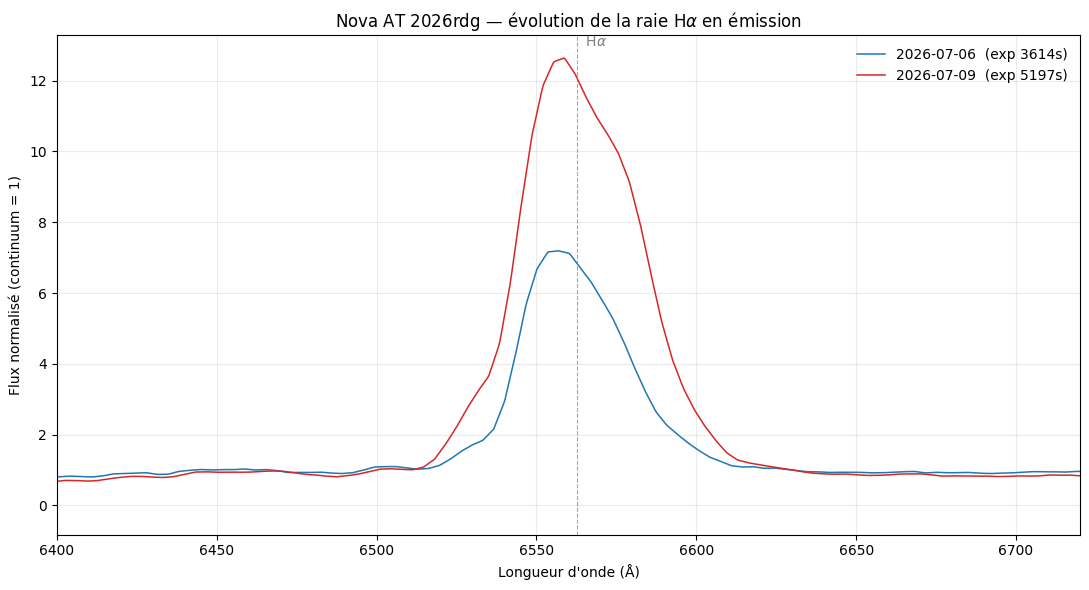

In [4]:
# --- Figure : zoom sur Hα ---
HALPHA = 6562.8
colors = {'2026-07-06': '#1f77b4', '2026-07-09': '#d62728'}

fig, ax = plt.subplots(figsize=(11, 6))
for label, (wl, flux, meta) in norm.items():
    ax.plot(wl, flux, color=colors.get(label), lw=1.1,
            label=f"{label}  (exp {int(meta['exptime'])}s)")

ax.axvline(HALPHA, color='gray', ls='--', lw=0.8, alpha=0.7)
ax.text(HALPHA, ax.get_ylim()[1], r'  H$\alpha$', color='gray',
        va='top', ha='left', fontsize=10)

ax.set_xlim(6400, 6720)
ax.set_xlabel('Longueur d\'onde (Å)')
ax.set_ylabel('Flux normalisé (continuum = 1)')
ax.set_title(r'Nova AT 2026rdg — évolution de la raie H$\alpha$ en émission')
ax.legend(frameon=False)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

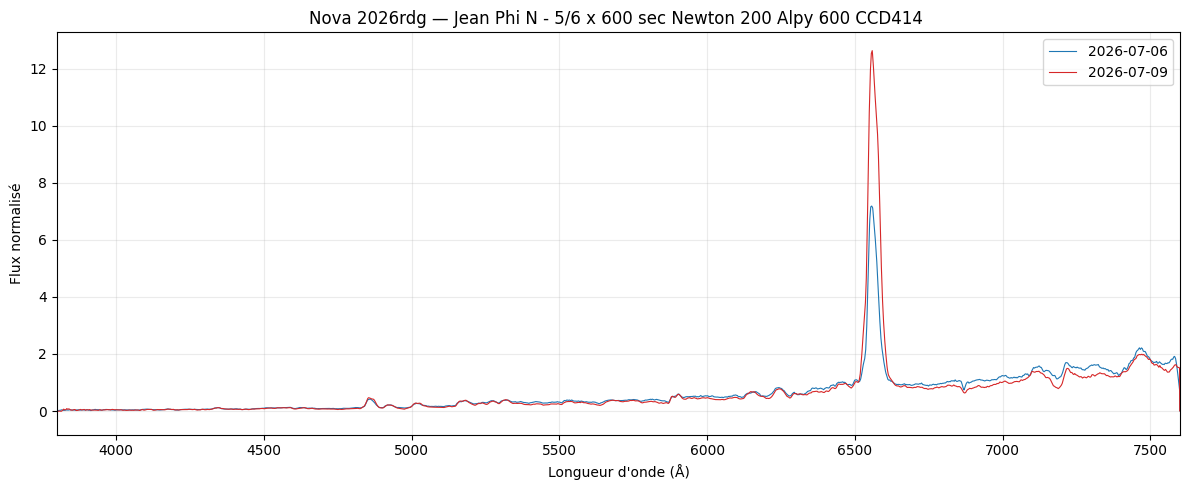

In [8]:
# --- Vue d'ensemble (spectre complet, même continuum) ---
fig, ax = plt.subplots(figsize=(12, 5))
for label, (wl, flux, meta) in norm.items():
    ax.plot(wl, flux, color=colors.get(label), lw=0.8, label=label)
ax.set_xlim(3800, 7600)
ax.set_xlabel('Longueur d\'onde (Å)')
ax.set_ylabel('Flux normalisé')
ax.set_title('Nova 2026rdg — Jean Phi N - 5/6 x 600 sec Newton 200 Alpy 600 CCD414 ')
ax.legend(frameon=True)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()